# SBI Binned SO Multi-Case Dataset Analysis

This notebook is based on `SBI_binned_SO.ipynb`, but targets the combined SO dataset produced by `SBI_analysis/build_so_multi_dataset.py`.

The current combined NPZ is expected to contain five binned linear `D_ell` SBI datavectors:

- `x_no_noise`
- `x_goal_deproj0`
- `x_baseline_deproj0`
- `x_goal_deproj2`
- `x_baseline_deproj2`

The `x_*` arrays are identical to `dl_binned_*`, with no floor and no log transform. Negative bins are allowed. The file also keeps binned raw `C_ell` arrays as `cl_binned_*`; if it was built without `--fast`, it may also contain large raw unbinned `cl_*` arrays. The default `x` key is an alias to one selected case so the file can be passed directly to `sbi_for_cluster.py` when needed.


In [122]:
from pathlib import Path
import ast
import json
import math
import os
import re
import struct
import sys
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import torch
except ModuleNotFoundError:
    torch = None

try:
    from sbi.inference import NPE
    from sbi.utils import BoxUniform
except ModuleNotFoundError:
    NPE = None
    BoxUniform = None

try:
    from getdist import plots, MCSamples
except ModuleNotFoundError:
    plots = None
    MCSamples = None

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
})


In [123]:
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "SBI_analysis").exists() and (candidate / "tSZ_visuals").exists():
            return candidate
    raise RuntimeError("Could not find project root containing SBI_analysis and tSZ_visuals")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "SBI_analysis"/ "data_for_cluster" / "so_multi_case_delta200_sbi_dataset.npz"
OUTPUT_DIR = PROJECT_ROOT / "SBI_analysis" / "outputs" / "so_multi_case_analysis" / "noise_fix"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_ROOT: \\wsl.localhost\myrootfs\home\cbllover\HalfDome
DATA_PATH: \\wsl.localhost\myrootfs\home\cbllover\HalfDome\SBI_analysis\data_for_cluster\so_multi_case_delta200_sbi_dataset.npz
OUTPUT_DIR: \\wsl.localhost\myrootfs\home\cbllover\HalfDome\SBI_analysis\outputs\so_multi_case_analysis\noise_fix


## Load Dataset

The helper below reads NPZ headers without loading every array. This matters because the unbinned `cl_*` arrays can be large.


In [124]:
def npz_headers(path):
    headers = {}
    with zipfile.ZipFile(path) as zf:
        for member in zf.namelist():
            if not member.endswith(".npy"):
                continue
            key = Path(member).stem
            with zf.open(member) as f:
                magic = f.read(6)
                if magic != b"\x93NUMPY":
                    continue
                major, minor = f.read(2)
                hlen_size = 2 if major == 1 else 4
                hlen_fmt = "<H" if major == 1 else "<I"
                hlen = struct.unpack(hlen_fmt, f.read(hlen_size))[0]
                header = ast.literal_eval(f.read(hlen).decode("latin1"))
                headers[key] = {
                    "shape": tuple(header["shape"]),
                    "dtype": header["descr"],
                    "fortran_order": bool(header["fortran_order"]),
                }
    return headers


def scalar_to_str(value):
    arr = np.asarray(value)
    if arr.shape == ():
        return str(arr.item())
    if arr.size == 1:
        return str(arr.reshape(-1)[0])
    return str(value)


def json_from_npz(data, key, default=None):
    if key not in data.files:
        return {} if default is None else default
    raw = scalar_to_str(data[key])
    try:
        parsed = json.loads(raw)
    except json.JSONDecodeError:
        return {} if default is None else default
    return parsed


if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing combined SO dataset: {DATA_PATH}\\n"
        "Create it with SBI_analysis/build_so_multi_dataset.py first."
    )

headers = npz_headers(DATA_PATH)
data = np.load(DATA_PATH, allow_pickle=True)
case_names = [str(x) for x in np.asarray(data["case_names"]).tolist()]
metadata = json_from_npz(data, "metadata_json")
binning = json_from_npz(data, "binning_json")

shape_df = pd.DataFrame(
    [
        {"key": key, "shape": headers[key]["shape"], "dtype": headers[key]["dtype"]}
        for key in sorted(headers)
    ]
)

display(shape_df)
print("cases:", case_names)
print("default_case:", scalar_to_str(data["default_case"]) if "default_case" in data.files else "")
print("metadata:")
print(json.dumps(metadata, indent=2)[:3000])


,key,shape,dtype
0,bin_counts,"(40,)",<i8
1,bin_ell_max,"(40,)",<f4
2,bin_ell_min,"(40,)",<f4
3,binning_json,(),<U648
4,case_names,"(5,)",<U16
5,cl_binned_baseline_deproj0,"(32768, 40)",<f4
6,cl_binned_baseline_deproj2,"(32768, 40)",<f4
7,cl_binned_goal_deproj0,"(32768, 40)",<f4
8,cl_binned_goal_deproj2,"(32768, 40)",<f4
9,cl_binned_no_noise,"(32768, 40)",<f4


cases: ['no_noise', 'goal_deproj0', 'baseline_deproj0', 'goal_deproj2', 'baseline_deproj2']
default_case: no_noise
metadata:
{
  "binning": {
    "bin_ell_max": [
      279,
      479,
      679,
      879,
      1079,
      1279,
      1479,
      1679,
      1879,
      2079,
      2279,
      2479,
      2679,
      2879,
      3079,
      3279,
      3479,
      3679,
      3879,
      4079,
      4279,
      4479,
      4679,
      4879,
      5079,
      5279,
      5479,
      5679,
      5879,
      6079,
      6279,
      6479,
      6679,
      6879,
      7079,
      7279,
      7479,
      7679,
      7879,
      7979
    ],
    "bin_ell_min": [
      80,
      280,
      480,
      680,
      880,
      1080,
      1280,
      1480,
      1680,
      1880,
      2080,
      2280,
      2480,
      2680,
      2880,
      3080,
      3280,
      3480,
      3680,
      3880,
      4080,
      4280,
      4480,
      4680,
      4880,
      5080,
      5280,
      5480,
    

## Core Arrays

`ell` is the binned SO `Delta ell = 200` grid. `ell_unbinned` is the original multipole grid used to construct binned `D_ell` and for optional raw-profile checks.


In [125]:
theta_np = np.asarray(data["theta"], dtype=np.float32)
param_names = [str(x) for x in np.asarray(data["param_names"]).tolist()]
prior_low_np = np.asarray(data["prior_low"], dtype=np.float32)
prior_high_np = np.asarray(data["prior_high"], dtype=np.float32)
prior_width_np = prior_high_np - prior_low_np

ell_np = np.asarray(data["ell"], dtype=np.float32)
ell_binned_np = np.asarray(data["ell_binned"], dtype=np.float32) if "ell_binned" in data.files else ell_np
ell_unbinned_np = np.asarray(data["ell_unbinned"], dtype=np.float32)
bin_ell_min_np = np.asarray(data["bin_ell_min"], dtype=np.float32)
bin_ell_max_np = np.asarray(data["bin_ell_max"], dtype=np.float32)
bin_counts_np = np.asarray(data["bin_counts"], dtype=np.int64)

print("theta:", theta_np.shape)
print("parameters:", param_names)
print("binned ell:", ell_np.shape, ell_np[0], ell_np[-1])
print("unbinned ell:", ell_unbinned_np.shape, ell_unbinned_np[0], ell_unbinned_np[-1])
print("bin ranges:", list(zip(bin_ell_min_np[:3], bin_ell_max_np[:3])), "...", list(zip(bin_ell_min_np[-3:], bin_ell_max_np[-3:])))

pd.DataFrame({
    "param": param_names,
    "prior_low": prior_low_np,
    "prior_high": prior_high_np,
    "prior_width": prior_width_np,
})


theta: (32768, 9)
parameters: ['P0', 'xc', 'beta', 'alpha_m_P0', 'alpha_m_xc', 'alpha_m_beta', 'alpha_z_P0', 'alpha_z_xc', 'alpha_z_beta']
binned ell: (40,) 198.01805 7929.605
unbinned ell: (7980,) 0.0 7979.0
bin ranges: [(80.0, 279.0), (280.0, 479.0), (480.0, 679.0)] ... [(7480.0, 7679.0), (7680.0, 7879.0), (7880.0, 7979.0)]


,param,prior_low,prior_high,prior_width
0,P0,1.832524,34.341221,32.508698
1,xc,0.150011,0.844503,0.694492
2,beta,3.480627,5.216611,1.735984
3,alpha_m_P0,0.000312,0.292251,0.291939
4,alpha_m_xc,-0.099718,0.099795,0.199513
5,alpha_m_beta,-0.019935,0.099767,0.119702
6,alpha_z_P0,-1.363457,-0.228839,1.134618
7,alpha_z_xc,0.147393,1.314474,1.167081
8,alpha_z_beta,0.083808,0.745884,0.662076


## Select A Case And Observation

Choose one of the five logical cases as the training datavector. The default observation is the saved Battaglia12 SO-noise profile for the same case. Set `OBS_SOURCE = "dataset-row"` to use a row from the combined Sobol dataset instead.


In [211]:
SELECTED_CASE = "goal_deproj0"   # no_noise, goal_deproj0, baseline_deproj0, goal_deproj2, baseline_deproj2
OBS_SOURCE = "dataset-row"       # battaglia12 or dataset-row
OBS_INDEX = -1                   # used only when OBS_SOURCE="dataset-row"; negative indices are allowed

# Optional ell cut for in-notebook plots/training/export. Use None for the full saved range.
ELL_MIN_ANALYSIS = None
ELL_MAX_ANALYSIS = None

# Datavector scaling used consistently for plots, in-notebook training, and exported SBI datasets.
# Options:
# - "standardize": (x - mean) / std
# - "asinh": asinh(x / median(abs(x)))
# - "asinh_standardize": standardize(asinh(x / median(abs(x))))
# Set RESCALE_X=False or X_RESCALE_MODE="none" to use raw D_ell.
# In the local training cell, asinh modes are recomputed from that train split with Torch.
RESCALE_X = True
X_RESCALE_MODE = "asinh"
X_RESCALE_EPS = 1.0e-30
X_STANDARDIZE_EPS = 1.0e-8

BATTAGLIA12_DIR = PROJECT_ROOT / "tSZ_visuals" / "outputs" / "so_noise_battaglia12_fiducial_local"
BATTAGLIA12_THETA_BY_NAME = {
    "P0": 18.1,
    "xc": 0.497,
    "beta": 4.35,
    "alpha_m_P0": 0.154,
    "alpha_m_xc": -0.00865,
    "alpha_m_beta": 0.0393,
    "alpha_z_P0": -0.758,
    "alpha_z_xc": 0.731,
    "alpha_z_beta": 0.415,
}
BATTAGLIA12_FILENAMES = {
    "no_noise": "halfdome_fullsky_masked_no_noise_cl_m200c_nside4096_base_cosmo_fid_gaussbeam_2p0arcmin_so_fsky0p4_apo60p0arcmin_seed12345_deproj0_lmax7979.npy",
    "goal_deproj0": "halfdome_fullsky_masked_goal_noise_cross_cl_m200c_nside4096_base_cosmo_fid_gaussbeam_2p0arcmin_so_fsky0p4_apo60p0arcmin_seed12345_deproj0_lmax7979.npy",
    "baseline_deproj0": "halfdome_fullsky_masked_baseline_noise_cross_cl_m200c_nside4096_base_cosmo_fid_gaussbeam_2p0arcmin_so_fsky0p4_apo60p0arcmin_seed12345_deproj0_lmax7979.npy",
    "goal_deproj2": "halfdome_fullsky_masked_goal_noise_cross_cl_m200c_nside4096_base_cosmo_fid_gaussbeam_2p0arcmin_so_fsky0p4_apo60p0arcmin_seed12345_deproj2_lmax7979.npy",
    "baseline_deproj2": "halfdome_fullsky_masked_baseline_noise_cross_cl_m200c_nside4096_base_cosmo_fid_gaussbeam_2p0arcmin_so_fsky0p4_apo60p0arcmin_seed12345_deproj2_lmax7979.npy",
}


def canonical_case_name(case):
    case = str(case)
    for prefix in ("x_", "dl_binned_", "cl_binned_"):
        if case.startswith(prefix):
            case = case[len(prefix):]
    return case


def resolve_obs_index(obs_index, n_rows):
    idx = int(obs_index)
    if idx < 0:
        idx = int(n_rows) + idx
    if not (0 <= idx < int(n_rows)):
        raise IndexError(
            f"OBS_INDEX={obs_index} resolves to {idx}, outside 0..{int(n_rows) - 1}"
        )
    return idx


def bin_weights_for_notebook(ell_values, weighting):
    ell_values = np.asarray(ell_values, dtype=np.float64)
    weighting = str(weighting or "2ell_plus_1").lower()
    if weighting in {"uniform", "none", "flat"}:
        return np.ones_like(ell_values, dtype=np.float64)
    if weighting == "ell":
        return ell_values
    if weighting in {"2ell_plus_1", "modes", "mode_count"}:
        return 2.0 * ell_values + 1.0
    raise ValueError(f"Unsupported bin weighting: {weighting!r}")


def make_notebook_bin_matrix(ell_unbinned, bin_min, bin_max, weighting):
    ell_unbinned = np.asarray(ell_unbinned, dtype=np.float64).reshape(-1)
    matrix = np.zeros((ell_unbinned.size, len(bin_min)), dtype=np.float64)
    for j, (lo, hi) in enumerate(zip(bin_min, bin_max)):
        idx = np.flatnonzero((ell_unbinned >= float(lo)) & (ell_unbinned <= float(hi)))
        if idx.size == 0:
            raise ValueError(f"No unbinned ell values found for bin {lo}-{hi}")
        w = bin_weights_for_notebook(ell_unbinned[idx], weighting)
        matrix[idx, j] = w / np.sum(w)
    return matrix


def read_profile_1d(path):
    arr = np.asarray(np.load(path))
    if arr.ndim == 1:
        return np.ascontiguousarray(arr, dtype=np.float32)
    if arr.ndim == 2 and 1 in arr.shape:
        return np.ascontiguousarray(arr.reshape(-1), dtype=np.float32)
    if arr.ndim == 2 and arr.shape[1] >= 2:
        return np.ascontiguousarray(arr[:, -1], dtype=np.float32)
    raise ValueError(f"Cannot interpret profile array from {path}: shape={arr.shape}")


def battaglia12_theta_vector():
    return np.asarray([BATTAGLIA12_THETA_BY_NAME[name] for name in param_names], dtype=np.float32)


def battaglia12_obs_vector(case, selected_mask):
    if case not in BATTAGLIA12_FILENAMES:
        raise KeyError(f"No Battaglia12 profile configured for case={case!r}")
    profile_path = BATTAGLIA12_DIR / BATTAGLIA12_FILENAMES[case]
    if not profile_path.is_file():
        raise FileNotFoundError(f"Missing Battaglia12 profile: {profile_path}")

    cl = read_profile_1d(profile_path)
    if cl.size != ell_unbinned_np.size:
        raise ValueError(f"{profile_path} length {cl.size} does not match ell_unbinned length {ell_unbinned_np.size}")

    weighting = binning.get("weighting", "2ell_plus_1")
    bin_matrix = make_notebook_bin_matrix(ell_unbinned_np, bin_ell_min_np, bin_ell_max_np, weighting)
    dl_factor = ell_unbinned_np.astype(np.float64) * (ell_unbinned_np.astype(np.float64) + 1.0) / (2.0 * np.pi)
    dl_binned = np.asarray(cl, dtype=np.float64) @ (dl_factor[:, None] * bin_matrix)
    return np.ascontiguousarray(dl_binned[selected_mask], dtype=np.float32), profile_path


selected_case = canonical_case_name(SELECTED_CASE)
if selected_case not in case_names:
    raise ValueError(f"SELECTED_CASE={SELECTED_CASE!r} resolves to {selected_case!r}, not in {case_names}")
SELECTED_CASE = selected_case

ell_mask = np.ones_like(ell_np, dtype=bool)
if ELL_MIN_ANALYSIS is not None:
    ell_mask &= ell_np >= float(ELL_MIN_ANALYSIS)
if ELL_MAX_ANALYSIS is not None:
    ell_mask &= ell_np <= float(ELL_MAX_ANALYSIS)
if not np.any(ell_mask):
    raise ValueError("The selected ell range contains no bins")
ell_plot_np = ell_np[ell_mask]
bin_counts_selected_np = bin_counts_np[ell_mask]
bin_ell_min_selected_np = bin_ell_min_np[ell_mask]
bin_ell_max_selected_np = bin_ell_max_np[ell_mask]


def normalize_x_scale_mode():
    if not bool(RESCALE_X):
        return "none"
    mode = str(X_RESCALE_MODE).strip().lower().replace("-", "_")
    aliases = {
        "": "standardize",
        "true": "standardize",
        "zscore": "standardize",
        "z_score": "standardize",
        "standardized": "standardize",
        "standardise": "standardize",
        "standardised": "standardize",
        "raw": "none",
        "false": "none",
        "off": "none",
        "no": "none",
        "arcsinh": "asinh",
        "asinh_zscore": "asinh_standardize",
        "asinh_z_score": "asinh_standardize",
        "asinh_standardized": "asinh_standardize",
        "standardize_asinh": "asinh_standardize",
        "zscore_asinh": "asinh_standardize",
    }
    mode = aliases.get(mode, mode)
    allowed = {"none", "standardize", "asinh", "asinh_standardize"}
    if mode not in allowed:
        raise ValueError(f"X_RESCALE_MODE must be one of {sorted(allowed)}, got {X_RESCALE_MODE!r}")
    return mode


active_x_scale_mode = normalize_x_scale_mode()
_case_transform_stats_cache = {}


def raw_case_x_selected(case):
    case = canonical_case_name(case)
    return np.asarray(data[f"x_{case}"][..., ell_mask], dtype=np.float32)


def case_transform_stats(case):
    case = canonical_case_name(case)
    if case not in _case_transform_stats_cache:
        x_all = np.asarray(data[f"x_{case}"], dtype=np.float32)

        raw_mean = np.mean(x_all, axis=0, dtype=np.float64).astype(np.float32)
        raw_std = np.std(x_all, axis=0, dtype=np.float64).astype(np.float32)
        raw_std = np.where(raw_std > float(X_STANDARDIZE_EPS), raw_std, 1.0).astype(np.float32)

        asinh_scale = np.median(np.abs(x_all), axis=0).astype(np.float32)
        asinh_scale = np.where(asinh_scale > float(X_RESCALE_EPS), asinh_scale, float(X_RESCALE_EPS)).astype(np.float32)

        x_all_asinh = np.arcsinh(x_all / asinh_scale)
        asinh_mean = np.mean(x_all_asinh, axis=0, dtype=np.float64).astype(np.float32)
        asinh_std = np.std(x_all_asinh, axis=0, dtype=np.float64).astype(np.float32)
        asinh_std = np.where(asinh_std > float(X_STANDARDIZE_EPS), asinh_std, 1.0).astype(np.float32)

        _case_transform_stats_cache[case] = {
            "raw_mean": raw_mean,
            "raw_std": raw_std,
            "asinh_scale": asinh_scale,
            "asinh_mean": asinh_mean,
            "asinh_std": asinh_std,
        }
    return _case_transform_stats_cache[case]


def case_scale_stats(case):
    stats = case_transform_stats(case)
    if active_x_scale_mode == "standardize":
        return stats["raw_mean"], stats["raw_std"]
    if active_x_scale_mode == "asinh_standardize":
        return stats["asinh_mean"], stats["asinh_std"]
    zeros = np.zeros_like(stats["raw_mean"], dtype=np.float32)
    ones = np.ones_like(stats["raw_std"], dtype=np.float32)
    return zeros, ones


def apply_case_scaling(case, values, selected_mask=ell_mask):
    arr = np.asarray(values, dtype=np.float32)
    mode = active_x_scale_mode
    stats = case_transform_stats(case)

    if mode == "standardize":
        arr = (arr - stats["raw_mean"][selected_mask]) / stats["raw_std"][selected_mask]
    elif mode == "asinh":
        arr = np.arcsinh(arr / stats["asinh_scale"][selected_mask])
    elif mode == "asinh_standardize":
        arr = np.arcsinh(arr / stats["asinh_scale"][selected_mask])
        arr = (arr - stats["asinh_mean"][selected_mask]) / stats["asinh_std"][selected_mask]

    return np.ascontiguousarray(arr, dtype=np.float32)


def case_x_selected(case):
    return apply_case_scaling(case, raw_case_x_selected(case), ell_mask)


def x_scale_file_tag():
    return {
        "none": "raw",
        "standardize": "zscore",
        "asinh": "asinh",
        "asinh_standardize": "asinh_zscore",
    }[active_x_scale_mode]


def x_datavector_ylabel():
    return {
        "none": r"$D_\ell$",
        "standardize": r"standardized $D_\ell$",
        "asinh": r"$\operatorname{asinh}(D_\ell / s_\ell)$",
        "asinh_standardize": r"standardized $\operatorname{asinh}(D_\ell / s_\ell)$",
    }[active_x_scale_mode]


obs_source = str(OBS_SOURCE).strip().lower().replace("_", "-")
if obs_source == "dataset-row":
    obs_index = resolve_obs_index(OBS_INDEX, theta_np.shape[0])
    x_np = case_x_selected(SELECTED_CASE)
    obs_raw_np = np.asarray(data[f"x_{SELECTED_CASE}"][obs_index, ell_mask], dtype=np.float32)
    obs_np = apply_case_scaling(SELECTED_CASE, obs_raw_np, ell_mask)
    theta_true_np = np.asarray(theta_np[obs_index], dtype=np.float32)
    obs_profile_path = None
elif obs_source == "battaglia12":
    obs_index = None
    x_np = case_x_selected(SELECTED_CASE)
    obs_raw_np, obs_profile_path = battaglia12_obs_vector(SELECTED_CASE, ell_mask)
    obs_np = apply_case_scaling(SELECTED_CASE, obs_raw_np, ell_mask)
    theta_true_np = battaglia12_theta_vector()
else:
    raise ValueError("OBS_SOURCE must be 'battaglia12' or 'dataset-row'")

print("selected case:", SELECTED_CASE)
print("obs source:", obs_source)
print("x scaling:", active_x_scale_mode)
print("rescale x:", bool(RESCALE_X))
print("x representation:", metadata.get("x_representation", "unknown"))
print("x shape:", x_np.shape)
print("obs shape:", obs_np.shape)
print("ell range:", float(ell_plot_np[0]), "...", float(ell_plot_np[-1]), f"({ell_plot_np.size} bins)")
print("obs index:", obs_index)
if obs_profile_path is not None:
    print("obs profile:", obs_profile_path)
print("theta truth:")
display(pd.DataFrame({"param": param_names, "truth": theta_true_np}))


selected case: goal_deproj0
obs source: dataset-row
x scaling: asinh
rescale x: True
x representation: binned_linear_d_ell
x shape: (32768, 40)
obs shape: (40,)
ell range: 198.01805114746094 ... 7929.60498046875 (40 bins)
obs index: 32767
theta truth:


,param,truth
0,P_0,15.851908
1,x_{\rm c},0.222086
2,\beta,4.434419
3,"\alpha_{m,P_0}",0.265726
4,"\alpha_{m,x_{\rm c}}",0.040675
5,"\alpha_{m,\beta}",0.009909
6,"\alpha_{z,P_0}",-0.481733
7,"\alpha_{z,x_{\rm c}}",0.694701
8,"\alpha_{z,\beta}",0.393559


In [212]:
obs_index

32767

## Plot The Five Binned Datavectors

These are the SBI vectors, already binned to SO `Delta ell = 200` and represented as linear `D_ell`. No floor or log transform is applied, so negative bins are allowed.


In [213]:
OUTPUT_DIR

WindowsPath('//wsl.localhost/myrootfs/home/cbllover/HalfDome/SBI_analysis/outputs/so_multi_case_analysis/noise_fix')

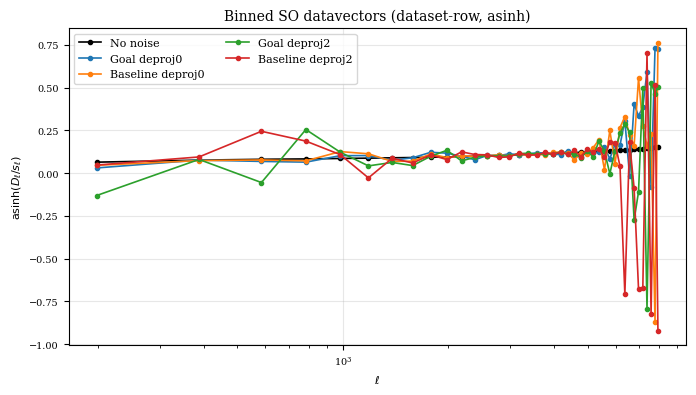

In [214]:
CASE_COLORS = {
    "no_noise": "black",
    "goal_deproj0": "tab:blue",
    "baseline_deproj0": "tab:orange",
    "goal_deproj2": "tab:green",
    "baseline_deproj2": "tab:red",
}

CASE_LABELS = {
    "no_noise": "No noise",
    "goal_deproj0": "Goal deproj0",
    "baseline_deproj0": "Baseline deproj0",
    "goal_deproj2": "Goal deproj2",
    "baseline_deproj2": "Baseline deproj2",
}

fig, ax = plt.subplots(figsize=(7, 4))
for case in case_names:
    if obs_source == "dataset-row":
        y = case_x_selected(case)[obs_index]
    else:
        case_obs_raw, _ = battaglia12_obs_vector(case, ell_mask)
        y = apply_case_scaling(case, case_obs_raw, ell_mask)
    ax.plot(
        ell_plot_np,
        y,
        marker="o",
        ms=3,
        lw=1.2,
        label=CASE_LABELS.get(case, case),
        color=CASE_COLORS.get(case),
    )

ax.set_xlabel(r"$\ell$")
ax.set_ylabel(x_datavector_ylabel())
ax.set_xscale("log")
ax.set_title(f"Binned SO datavectors ({obs_source}, {x_scale_file_tag()})")
ax.grid(True, alpha=0.3)
ax.legend(ncols=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"binned_dl_{obs_source}_{SELECTED_CASE}_{x_scale_file_tag()}.png", dpi=220)
plt.show()


In [215]:
np.arcsinh(y)

array([ 0.04672075,  0.09425147,  0.24209619,  0.18594044,  0.10750837,
       -0.02807471,  0.08641791,  0.05910527,  0.10643767,  0.07881226,
        0.12375443,  0.10835311,  0.10631587,  0.09137323,  0.09439223,
        0.11600539,  0.10510337,  0.10583155,  0.12104914,  0.11013   ,
        0.12209481,  0.11015154,  0.131749  ,  0.09671891,  0.13952321,
        0.12109869,  0.14295058,  0.09279659,  0.18272643,  0.1772678 ,
        0.03925859, -0.65997565,  0.17949322, -0.08728807, -0.6343986 ,
       -0.62835425,  0.6539406 , -0.75029933,  0.4965869 , -0.8252299 ],
      dtype=float32)

In [216]:
y

array([ 0.04673775,  0.09439108,  0.24446803,  0.18701375,  0.10771558,
       -0.0280784 ,  0.08652551,  0.05913969,  0.10663875,  0.07889386,
        0.12407056,  0.10856526,  0.10651627,  0.09150043,  0.09453245,
        0.11626575,  0.10529699,  0.10602922,  0.12134498,  0.11035275,
        0.12239839,  0.11037444,  0.13213047,  0.09686977,  0.13997632,
        0.12139489,  0.14343794,  0.09292983,  0.18374497,  0.17819767,
        0.03926868, -0.7089406 ,  0.18045859, -0.08739895, -0.6778167 ,
       -0.67052704,  0.7015558 , -0.8227043 ,  0.51724964, -0.9221356 ],
      dtype=float32)

## Noise Offsets Relative To No Noise

The next plot shows case minus no-noise in binned linear `D_ell` space for the selected row or Battaglia12 observation.


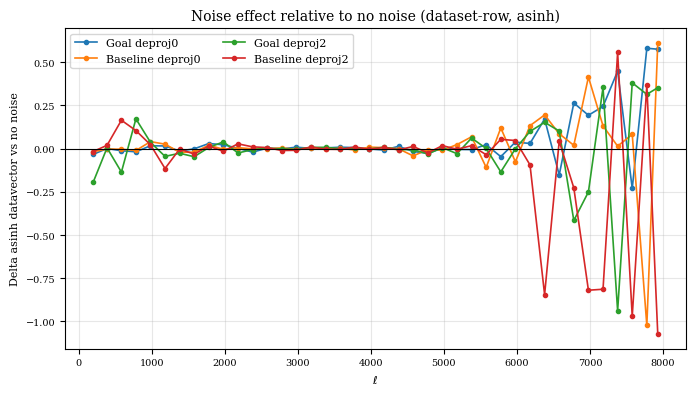

In [217]:
if obs_source == "dataset-row":
    x_no_noise_raw = np.asarray(data["x_no_noise"][obs_index, ell_mask], dtype=np.float32)
else:
    x_no_noise_raw, _ = battaglia12_obs_vector("no_noise", ell_mask)
x_no_noise_row = apply_case_scaling("no_noise", x_no_noise_raw, ell_mask)

fig, ax = plt.subplots(figsize=(7, 4))
for case in case_names:
    if case == "no_noise":
        continue
    if obs_source == "dataset-row":
        case_raw = np.asarray(data[f"x_{case}"][obs_index, ell_mask], dtype=np.float32)
    else:
        case_raw, _ = battaglia12_obs_vector(case, ell_mask)
    y = apply_case_scaling(case, case_raw, ell_mask) - x_no_noise_row
    ax.plot(ell_plot_np, y, marker="o", ms=3, lw=1.2, label=CASE_LABELS.get(case, case), color=CASE_COLORS.get(case))

ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel(r"$\ell$")
if active_x_scale_mode == "none":
    ax.set_ylabel(r"$\Delta D_\ell$ vs no noise")
else:
    ax.set_ylabel(f"Delta {x_scale_file_tag()} datavector vs no noise")
ax.set_title(f"Noise effect relative to no noise ({obs_source}, {x_scale_file_tag()})")
ax.grid(True, alpha=0.3)
ax.legend(ncols=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"binned_dl_delta_vs_no_noise_{obs_source}_{x_scale_file_tag()}.png", dpi=220)
plt.show()


## Dataset-Level Summary Per Case

This computes simple binned-vector summaries over all rows. It loads only the binned `x_*` arrays, not the large unbinned `cl_*` arrays.


In [218]:
summary_rows = []
for case in case_names:
    arr = case_x_selected(case)
    summary_rows.append({
        "case": case,
        "x_scale_mode": active_x_scale_mode,
        "rows": arr.shape[0],
        "bins": arr.shape[1],
        "finite": bool(np.all(np.isfinite(arr))),
        "min": float(np.nanmin(arr)),
        "median": float(np.nanmedian(arr)),
        "max": float(np.nanmax(arr)),
    })

case_summary_df = pd.DataFrame(summary_rows)
display(case_summary_df)
case_summary_df.to_csv(OUTPUT_DIR / f"case_summary_{x_scale_file_tag()}.csv", index=False)


,case,x_scale_mode,rows,bins,finite,min,median,max
0,no_noise,asinh,32768,40,True,0.000004,0.881374,8.882566
1,goal_deproj0,asinh,32768,40,True,-0.268944,0.881374,8.895962
2,baseline_deproj0,asinh,32768,40,True,-0.940839,0.859068,8.909322
3,goal_deproj2,asinh,32768,40,True,-0.914619,0.868826,8.930432
4,baseline_deproj2,asinh,32768,40,True,-0.937073,0.814286,9.005289


## Binned D_ell Checks

The builder stores binned linear `D_ell` as `dl_binned_*`. This cell checks that the saved `x_*` values are exactly the same binned linear `D_ell` arrays.


In [219]:
check_rows = []
for case in case_names:
    x_recomputed = np.asarray(data[f"dl_binned_{case}"][..., ell_mask], dtype=np.float64)
    x_saved = np.asarray(data[f"x_{case}"][..., ell_mask], dtype=np.float64)
    diff = x_recomputed - x_saved
    check_rows.append({
        "case": case,
        "max_abs_diff": float(np.nanmax(np.abs(diff))),
        "rms_diff": float(np.sqrt(np.nanmean(diff**2))),
    })

check_df = pd.DataFrame(check_rows)
display(check_df)


,case,max_abs_diff,rms_diff
0,no_noise,0.0,0.0
1,goal_deproj0,0.0,0.0
2,baseline_deproj0,0.0,0.0
3,goal_deproj2,0.0,0.0
4,baseline_deproj2,0.0,0.0


## Optional: Plot Unbinned C_ell

Set `PLOT_UNBINNED = True` to load the raw unbinned `cl_*` arrays for one row. For a large full dataset this can be memory-heavy because compressed NPZ members are loaded as whole arrays.


In [220]:
PLOT_UNBINNED = False

if PLOT_UNBINNED:
    missing_cl = [case for case in case_names if f"cl_{case}" not in data.files]
    if missing_cl:
        raise KeyError(f"Unbinned cl_* arrays are missing for {missing_cl}. Rebuild without --fast/--skip-unbinned-cl.")

    fig, ax = plt.subplots(figsize=(7, 4))
    for case in case_names:
        cl = np.asarray(data[f"cl_{case}"][obs_index if obs_index is not None else -1], dtype=np.float64)
        dl = cl * ell_unbinned_np * (ell_unbinned_np + 1.0) / (2.0 * np.pi)
        ok = np.isfinite(dl) & (dl > 0) & (ell_unbinned_np >= 2)
        ax.loglog(ell_unbinned_np[ok], dl[ok], lw=1.0, label=CASE_LABELS.get(case, case), color=CASE_COLORS.get(case))

    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(r"$D_\ell$")
    ax.set_title(f"Unbinned raw spectra ({obs_source})")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(ncols=2)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"unbinned_dl_{obs_source}.png", dpi=220)
    plt.show()
else:
    print("Set PLOT_UNBINNED=True to load and plot raw unbinned cl_* arrays.")


Set PLOT_UNBINNED=True to load and plot raw unbinned cl_* arrays.


## Export A Case-Specific SBI Dataset

`sbi_for_cluster.py` reads the generic keys `theta`, `x`, `obs`, `ell`, `prior_low`, and `prior_high`. Use this helper to write a compact case-specific NPZ from the combined file. By default it uses the same `OBS_SOURCE` and ell selection as above.


In [221]:
def write_case_sbi_dataset(case, output_path=None, obs_index=-1, obs_case=None, obs_source=None):
    case = canonical_case_name(case)
    if case not in case_names:
        raise ValueError(f"case must be one of {case_names}")
    obs_case = case if obs_case is None else canonical_case_name(obs_case)
    if obs_case not in case_names:
        raise ValueError(f"obs_case must be one of {case_names}")
    obs_source = OBS_SOURCE if obs_source is None else obs_source
    obs_source = str(obs_source).strip().lower().replace("_", "-")

    if output_path is None:
        tag = "battaglia12" if obs_source == "battaglia12" else f"obs{obs_index}"
        output_path = DATA_PATH.with_name(f"{DATA_PATH.stem}_{case}_{tag}_{x_scale_file_tag()}_sbi_run.npz")
    output_path = Path(output_path)

    x_case = case_x_selected(case)
    case_stats = case_transform_stats(case)
    obs_stats = case_transform_stats(obs_case)
    x_scale_mean, x_scale_std = case_scale_stats(case)
    obs_scale_mean, obs_scale_std = case_scale_stats(obs_case)

    if obs_source == "battaglia12":
        obs_raw, obs_profile = battaglia12_obs_vector(obs_case, ell_mask)
        obs_vec = apply_case_scaling(obs_case, obs_raw, ell_mask)
        obs_theta = battaglia12_theta_vector()
        idx_payload = np.asarray(-1, dtype=np.int64)
        obs_profile_text = str(obs_profile)
    elif obs_source == "dataset-row":
        idx = resolve_obs_index(obs_index, theta_np.shape[0])
        obs_raw = np.asarray(data[f"x_{obs_case}"][idx, ell_mask], dtype=np.float32)
        obs_vec = apply_case_scaling(obs_case, obs_raw, ell_mask)
        obs_theta = np.asarray(theta_np[idx], dtype=np.float32)
        idx_payload = np.asarray(idx, dtype=np.int64)
        obs_profile_text = ""
    else:
        raise ValueError("obs_source must be 'battaglia12' or 'dataset-row'")

    payload = {
        "theta": theta_np,
        "x": x_case,
        "obs": obs_vec,
        "obs_theta": obs_theta,
        "obs_index": idx_payload,
        "obs_source": np.asarray(obs_source),
        "obs_profile_path": np.asarray(obs_profile_text),
        "ell": ell_plot_np,
        "ell_binned": ell_plot_np,
        "prior_low": prior_low_np,
        "prior_high": prior_high_np,
        "param_names": np.asarray(param_names, dtype=str),
        "case_name": np.asarray(case),
        "obs_case_name": np.asarray(obs_case),
        "x_rescale_enabled": np.asarray(bool(RESCALE_X)),
        "x_rescale_mode": np.asarray(active_x_scale_mode),
        "x_scale_mean": x_scale_mean[ell_mask],
        "x_scale_std": x_scale_std[ell_mask],
        "x_raw_mean": case_stats["raw_mean"][ell_mask],
        "x_raw_std": case_stats["raw_std"][ell_mask],
        "x_asinh_scale": case_stats["asinh_scale"][ell_mask],
        "x_asinh_mean": case_stats["asinh_mean"][ell_mask],
        "x_asinh_std": case_stats["asinh_std"][ell_mask],
        "obs_x_scale_mean": obs_scale_mean[ell_mask],
        "obs_x_scale_std": obs_scale_std[ell_mask],
        "obs_x_raw_mean": obs_stats["raw_mean"][ell_mask],
        "obs_x_raw_std": obs_stats["raw_std"][ell_mask],
        "obs_x_asinh_scale": obs_stats["asinh_scale"][ell_mask],
        "obs_x_asinh_mean": obs_stats["asinh_mean"][ell_mask],
        "obs_x_asinh_std": obs_stats["asinh_std"][ell_mask],
        "bin_counts": bin_counts_selected_np,
        "bin_ell_min": bin_ell_min_selected_np,
        "bin_ell_max": bin_ell_max_selected_np,
        "binning_json": np.asarray(json.dumps(binning, sort_keys=True)),
        "metadata_json": np.asarray(json.dumps({
            "source_combined_dataset": str(DATA_PATH),
            "case": case,
            "obs_case": obs_case,
            "obs_source": obs_source,
            "obs_profile_path": obs_profile_text,
            "obs_index": int(idx_payload),
            "x_representation": metadata.get("x_representation", "binned_linear_d_ell"),
            "x_rescale_enabled": bool(RESCALE_X),
            "x_rescale_mode": active_x_scale_mode,
            "x_rescale_eps": float(X_RESCALE_EPS),
            "x_standardize_eps": float(X_STANDARDIZE_EPS),
            "ell_min_analysis": None if ELL_MIN_ANALYSIS is None else float(ELL_MIN_ANALYSIS),
            "ell_max_analysis": None if ELL_MAX_ANALYSIS is None else float(ELL_MAX_ANALYSIS),
            "x_shape": list(x_case.shape),
            "theta_shape": list(theta_np.shape),
        }, sort_keys=True)),
    }

    output_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(output_path, **payload)
    return output_path


CASE_DATASET_PATH = write_case_sbi_dataset(SELECTED_CASE, obs_index=OBS_INDEX, obs_source=OBS_SOURCE)
print("Wrote case-specific SBI dataset:", CASE_DATASET_PATH)
print("Use with PREPARED_DATASET_PATH=", CASE_DATASET_PATH)


Wrote case-specific SBI dataset: \\wsl.localhost\myrootfs\home\cbllover\HalfDome\SBI_analysis\data_for_cluster\so_multi_case_delta200_sbi_dataset_goal_deproj0_obs-1_asinh_sbi_run.npz
Use with PREPARED_DATASET_PATH= \\wsl.localhost\myrootfs\home\cbllover\HalfDome\SBI_analysis\data_for_cluster\so_multi_case_delta200_sbi_dataset_goal_deproj0_obs-1_asinh_sbi_run.npz


## Tensors For In-Notebook SBI

The next cells mirror the SBI setup in `SBI_binned_SO.ipynb`, but they are optional. Cluster runs should use the case-specific NPZ path printed above.


In [222]:
if torch is None:
    print("torch is not available in this kernel")
else:
    theta_t = torch.as_tensor(theta_np, dtype=torch.float32)
    x_t = torch.as_tensor(x_np, dtype=torch.float32)
    obs_t = torch.as_tensor(obs_np, dtype=torch.float32)

    prior_t = None
    if BoxUniform is not None:
        prior_t = BoxUniform(
            low=torch.as_tensor(prior_low_np, dtype=torch.float32),
            high=torch.as_tensor(prior_high_np, dtype=torch.float32),
        )

    print("theta_t:", tuple(theta_t.shape))
    print("x_t:", tuple(x_t.shape))
    print("obs_t:", tuple(obs_t.shape))
    print("prior_t:", prior_t)


theta_t: (32768, 9)
x_t: (32768, 40)
obs_t: (40,)
prior_t: BoxUniform(Uniform(low: torch.Size([9]), high: torch.Size([9])), 1)


## Optional: Train A Small SBI Posterior

Set `RUN_TRAINING = True` to run a local NPE test. Keep `N_TRAIN` small for a notebook sanity check.


In [223]:
N = 500
x_train[N]

tensor([0.8726, 1.0023, 1.1309, 1.2292, 1.3060, 1.3711, 1.4292, 1.4758, 1.5212,
        1.5580, 1.5862, 1.6127, 1.6391, 1.6574, 1.6785, 1.6943, 1.7082, 1.7217,
        1.7332, 1.7427, 1.7488, 1.7605, 1.7607, 1.7642, 1.7735, 1.7750, 1.7785,
        1.7865, 1.7749, 1.7911, 1.7905, 1.8194, 1.7527, 1.8354, 1.8230, 1.8264,
        1.8614, 1.7235, 1.8410, 1.8223])

In [242]:

try:
    from sbi.neural_nets import posterior_nn
except ImportError:
    from sbi.utils.get_nn_models import posterior_nn  # older sbi versions

RUN_TRAINING = True
N_TRAIN = min(32000, theta_np.shape[0])
NUM_POSTERIOR_SAMPLES = 50_000
DENSITY_ESTIMATOR = "zuko_maf"      # use "zuko_maf" if your sbi environment supports it
STOP_AFTER_EPOCHS = 45
SEED = 42

posterior_samples = None
posterior = None

if RUN_TRAINING:
    if torch is None or NPE is None or BoxUniform is None:
        raise RuntimeError("Install torch and sbi before running this cell")

    rng = np.random.default_rng(SEED)
    train_idx = rng.permutation(theta_np.shape[0])[:N_TRAIN]
    theta_train = torch.as_tensor(theta_np[train_idx], dtype=torch.float32)

    if active_x_scale_mode in {"asinh", "asinh_standardize"}:
        # For asinh modes, compute the transform from the actual training split.
        x_train_raw = torch.as_tensor(raw_case_x_selected(SELECTED_CASE)[train_idx], dtype=torch.float32)
        x_o = torch.as_tensor(obs_raw_np, dtype=torch.float32)

        scale = torch.median(torch.abs(x_train_raw), dim=0).values
        scale = torch.clamp(scale, min=float(X_RESCALE_EPS))

        x_train_asinh = torch.asinh(x_train_raw / scale)
        x_obs_asinh = torch.asinh(x_o / scale)

        if active_x_scale_mode == "asinh_standardize":
            x_mean = x_train_asinh.mean(dim=0)
            x_std = x_train_asinh.std(dim=0)
            x_std = torch.clamp(x_std, min=float(X_STANDARDIZE_EPS))

            x_train = (x_train_asinh - x_mean) / x_std
            obs_train = (x_obs_asinh - x_mean) / x_std
        else:
            x_train = x_train_asinh
            obs_train = x_obs_asinh
    else:
        x_train = torch.as_tensor(x_np[train_idx], dtype=torch.float32)
        obs_train = torch.as_tensor(obs_np, dtype=torch.float32)

    prior = BoxUniform(
        low=torch.as_tensor(prior_low_np, dtype=torch.float32),
        high=torch.as_tensor(prior_high_np, dtype=torch.float32),
    )

    density_estimator = posterior_nn(
            model=DENSITY_ESTIMATOR,
            hidden_features=128,
            num_transforms=8,
        )

    inference = NPE(prior=prior, density_estimator=density_estimator)
    density_estimator = inference.append_simulations(theta_train, x_train).train(
        stop_after_epochs=STOP_AFTER_EPOCHS,
        show_train_summary=True,
    )
    posterior = inference.build_posterior(density_estimator)
    posterior_samples_t = posterior.sample((NUM_POSTERIOR_SAMPLES,), x=obs_train)
    posterior_samples = posterior_samples_t.detach().cpu().numpy() if torch.is_tensor(posterior_samples_t) else np.asarray(posterior_samples_t)

    tag = "battaglia12" if obs_source == "battaglia12" else f"obs{obs_index}"
    sample_path = OUTPUT_DIR / f"posterior_samples_{SELECTED_CASE}_N{N_TRAIN}_{tag}_{x_scale_file_tag()}_additional_features.npy"
    np.save(sample_path, posterior_samples)
    print("saved posterior samples:", sample_path)
else:
    print("RUN_TRAINING=False; skipping local SBI training")


 Neural network successfully converged after 594 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 594
        Best validation performance: -13.4024
        -------------------------
        


  0%|          | 0/50000 [00:00<?, ?it/s]

saved posterior samples: \\wsl.localhost\myrootfs\home\cbllover\HalfDome\SBI_analysis\outputs\so_multi_case_analysis\noise_fix\posterior_samples_goal_deproj0_N32000_obs32767_asinh_additional_features.npy


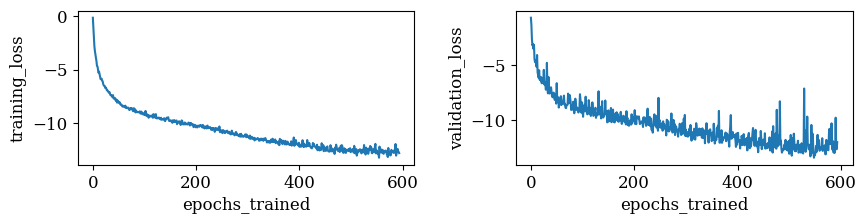

In [243]:
from sbi.analysis import plot_summary

_ = plot_summary(
    inference,
    tags=["training_loss", "validation_loss"],
    figsize=(10, 2),
)

In [ ]:
ell_np[:28]

array([ 198.01805,  388.2717 ,  585.247  ,  783.7734 ,  982.90125,
       1182.3248 , 1381.9154 , 1581.6096 , 1781.3726 , 1981.1835 ,
       2181.029  , 2380.9006 , 2580.792  , 2780.699  , 2980.6187 ,
       3180.548  , 3380.486  , 3580.4312 , 3780.3818 , 3980.3374 ,
       4180.2974 , 4380.261  , 4580.228  , 4780.1973 , 4980.1694 ,
       5180.1436 , 5380.1196 , 5580.097  ], dtype=float32)

## Posterior Diagnostics If Samples Exist

This cell works after the optional training cell, or after loading a saved posterior sample file into `posterior_samples`.


,param,truth,mean,std,std_over_prior,pull
0,P_0,15.851908,18.864315,5.175479,0.159203,0.582054
1,x_{\rm c},0.222086,0.262680,0.055091,0.079326,0.736862
2,\beta,4.434419,4.511251,0.376905,0.217113,0.203849
3,"\alpha_{m,P_0}",0.265726,0.185731,0.056095,0.192147,-1.426061
4,"\alpha_{m,x_{\rm c}}",0.040675,0.030624,0.038270,0.191815,-0.262629
5,"\alpha_{m,\beta}",0.009909,0.035502,0.027779,0.232064,0.921300
6,"\alpha_{z,P_0}",-0.481733,-0.813143,0.257929,0.227327,-1.284886
7,"\alpha_{z,x_{\rm c}}",0.694701,0.652347,0.229347,0.196513,-0.184669
8,"\alpha_{z,\beta}",0.393559,0.412775,0.148854,0.224829,0.129094


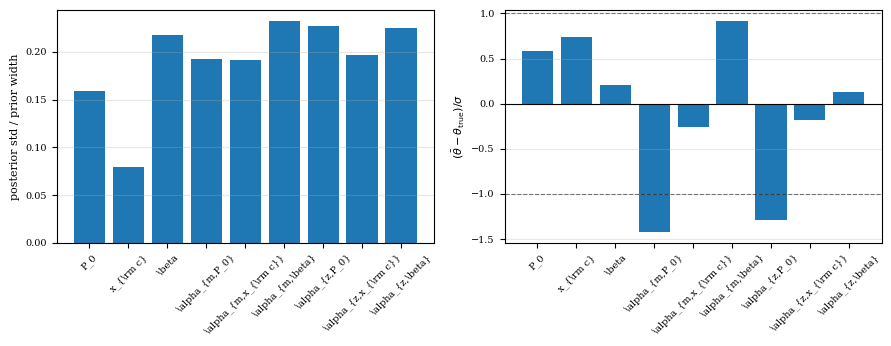

In [245]:
if posterior_samples is None:
    print("No posterior_samples in memory yet.")
else:
    mean = posterior_samples.mean(axis=0)
    std = posterior_samples.std(axis=0, ddof=1)
    pull = (mean - theta_true_np[: posterior_samples.shape[1]]) / std
    std_over_prior = std / prior_width_np[: posterior_samples.shape[1]]

    diag_df = pd.DataFrame({
        "param": param_names[: posterior_samples.shape[1]],
        "truth": theta_true_np[: posterior_samples.shape[1]],
        "mean": mean,
        "std": std,
        "std_over_prior": std_over_prior,
        "pull": pull,
    })
    display(diag_df)

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    axes[0].bar(diag_df["param"], diag_df["std_over_prior"])
    axes[0].set_ylabel("posterior std / prior width")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].grid(True, axis="y", alpha=0.3)

    axes[1].bar(diag_df["param"], diag_df["pull"])
    axes[1].axhline(0, color="k", lw=0.8)
    axes[1].axhline(1, color="k", lw=0.8, ls="--", alpha=0.5)
    axes[1].axhline(-1, color="k", lw=0.8, ls="--", alpha=0.5)
    axes[1].set_ylabel(r"$(\bar{\theta} - \theta_{\rm true}) / \sigma$")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].grid(True, axis="y", alpha=0.3)

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"posterior_diagnostics_{SELECTED_CASE}_N{N_TRAIN}_obs{obs_index}.png", dpi=220)
    plt.show()


In [246]:
f"posterior_samples_{SELECTED_CASE}_N{N_TRAIN}_{tag}_{x_scale_file_tag()}.npy"

'posterior_samples_goal_deproj0_N32000_obs32767_asinh.npy'

## Optional GetDist Triangle

This is skipped unless `posterior_samples` exists and `getdist` is installed.


In [254]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from getdist import plots, MCSamples


def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def load_samples(x):
    if isinstance(x, (str, Path)):
        return np.load(x)
    return to_numpy(x)


def make_getdist_samples(
    sample_sets,
    param_names,
    labels_latex,
    max_params=None,
):
    """
    sample_sets = [
        {"samples": array_or_path, "label": "goal deproj0"},
        {"samples": array_or_path, "label": "baseline deproj0"},
    ]
    """
    samples_np_list = [load_samples(s["samples"]) for s in sample_sets]

    n_params = min(s.shape[1] for s in samples_np_list)
    if max_params is not None:
        n_params = min(n_params, max_params)

    names = [f"p{i}" for i in range(n_params)]
    labels = labels_latex[:n_params]

    gd_samples = []

    for spec, samples_np in zip(sample_sets, samples_np_list):
        samples_np = np.asarray(samples_np[:, :n_params], dtype=float)

        gd = MCSamples(
            samples=samples_np,
            names=names,
            labels=labels,
            label=spec["label"],
        )

        gd.updateSettings({
            "smooth_scale_1D": 0.3,
            "smooth_scale_2D": 0.3,
            "fine_bins": 2048,
            "fine_bins_2D": 1024,
        })

        gd_samples.append(gd)

    return gd_samples, names, n_params


label_by_name = {
    "P0": r"P_0",
    "xc": r"x_{\rm c}",
    "beta": r"\beta",
    "alpha_m_P0": r"\alpha_{m,P_0}",
    "alpha_m_xc": r"\alpha_{m,x_{\rm c}}",
    "alpha_m_beta": r"\alpha_{m,\beta}",
    "alpha_z_P0": r"\alpha_{z,P_0}",
    "alpha_z_xc": r"\alpha_{z,x_{\rm c}}",
    "alpha_z_beta": r"\alpha_{z,\beta}",
}

labels_latex = [label_by_name[p] for p in param_names]

KeyError: 'P_0'

In [255]:
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def sample_set_label(sample_set, i):
    if isinstance(sample_set, dict):
        return sample_set.get("label", f"set {i + 1}")
    return f"set {i + 1}"


def find_samples_in_dict(d, label, expected_n_params):
    preferred_keys = [
        "samples",
        "posterior_samples",
        "posterior_np",
        "posterior",
        "chain",
        "values",
    ]

    # First try preferred keys.
    for key in preferred_keys:
        if key not in d:
            continue

        arr = to_numpy(d[key])
        if arr.ndim == 2:
            return arr, key
        if arr.ndim == 3 and arr.shape[0] == 1:
            return arr[0], key

    # Then search every dict value for a 2D sample-like array.
    candidates = []
    for key, value in d.items():
        try:
            arr = to_numpy(value)
        except Exception:
            continue

        if arr.ndim == 2 and arr.shape[1] == expected_n_params:
            candidates.append((key, arr))
        elif arr.ndim == 2 and arr.shape[0] > 100 and arr.shape[1] <= expected_n_params:
            candidates.append((key, arr))
        elif arr.ndim == 3 and arr.shape[0] == 1 and arr.shape[-1] <= expected_n_params:
            candidates.append((key, arr[0]))

    if candidates:
        key, arr = candidates[0]
        return arr, key

    print(f"\nCould not find posterior samples for {label}.")
    print("Available keys and shapes:")
    for key, value in d.items():
        try:
            arr = to_numpy(value)
            print(f"  {key}: shape={arr.shape}, dtype={arr.dtype}")
        except Exception:
            print(f"  {key}: type={type(value)}")

    raise ValueError(f"No 2D posterior sample array found for {label}")


def sample_set_samples(sample_set, i, expected_n_params):
    label = sample_set_label(sample_set, i)

    if isinstance(sample_set, dict):
        arr, key = find_samples_in_dict(sample_set, label, expected_n_params)
        print(f"{label}: using key {key!r}, shape={arr.shape}")
        return arr

    arr = to_numpy(sample_set)
    print(f"{label}: direct array, shape={arr.shape}")
    return arr


def make_getdist_samples(sample_sets, param_names, labels_latex):
    expected_n_params = len(param_names)

    samples_np_list = [
        sample_set_samples(s, i, expected_n_params)
        for i, s in enumerate(sample_sets)
    ]

    n_params = min(
        min(s.shape[1] for s in samples_np_list),
        len(param_names),
        len(labels_latex),
    )

    names = [f"p{i}" for i in range(n_params)]
    labels = list(labels_latex[:n_params])

    gd_samples = []

    for i, samples_np in enumerate(samples_np_list):
        gd = MCSamples(
            samples=np.asarray(samples_np[:, :n_params], dtype=float),
            names=names,
            labels=labels,
            label=sample_set_label(sample_sets[i], i),
        )

        gd.updateSettings({
            "smooth_scale_1D": 0.3,
            "smooth_scale_2D": 0.3,
            "fine_bins": 2048,
            "fine_bins_2D": 1024,
        })

        gd_samples.append(gd)

    return gd_samples, names, n_params

In [256]:
RUN_ROOT = Path("../SBI_analysis/outputs/cluster_outputs/SBI_SO_no_noise_dataset_size_analysis")

sample_sets = [
            {
        "samples": OUTPUT_DIR / f"posterior_samples_goal_deproj0_N32000_obs32767_zscore.npy",
        "label": r"$N=32{,}000$ obs-1 index (standardize)",
    },

            {
        "samples": OUTPUT_DIR / f"posterior_samples_goal_deproj0_N32000_obs32767_raw.npy",
        "label": r"$N=32{,}000$ obs-1 index (no rescale)",
    },

                {
        "samples": OUTPUT_DIR / f"posterior_samples_goal_deproj0_N32000_obs32767_asinh_zscore.npy",
        "label": r"$N=32{,}000$ obs-1 index (asin(x/s) + standardize)",
    },
    
                    {
        "samples": OUTPUT_DIR / f"posterior_samples_goal_deproj0_N32000_obs32767_asinh.npy",
        "label": r"$N=32{,}000$ obs-1 index (asin(x/s))",
    },
                    {
        "samples": OUTPUT_DIR / f"posterior_samples_goal_deproj0_N32000_obs32767_asinh_additional_features.npy",
        "label": r"$N=32{,}000$ obs-1 index (asin(x/s)) add. NPE features",
    },
]

In [257]:
ell_np[:28]

array([ 198.01805,  388.2717 ,  585.247  ,  783.7734 ,  982.90125,
       1182.3248 , 1381.9154 , 1581.6096 , 1781.3726 , 1981.1835 ,
       2181.029  , 2380.9006 , 2580.792  , 2780.699  , 2980.6187 ,
       3180.548  , 3380.486  , 3580.4312 , 3780.3818 , 3980.3374 ,
       4180.2974 , 4380.261  , 4580.228  , 4780.1973 , 4980.1694 ,
       5180.1436 , 5380.1196 , 5580.097  ], dtype=float32)

In [258]:
true_params_plot = theta_true_np[:n_params]
print(true_params_plot)


[ 1.5851908e+01  2.2208552e-01  4.4344192e+00  2.6572648e-01
  4.0674653e-02  9.9093253e-03 -4.8173320e-01  6.9470060e-01
  3.9355853e-01]


In [259]:
def unpack_samples(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    x = np.asarray(x)
    while x.shape == () and x.dtype == object:
        x = np.asarray(x.item())
    return x


samples_np_list = [
    unpack_samples(s["samples"])
    for s in sample_sets
]

labels_plot = [
    s.get("label", f"set {i+1}")
    for i, s in enumerate(sample_sets)
]

n_params = min(s.shape[1] for s in samples_np_list)
names = [f"p{i}" for i in range(n_params)]
labels = labels_latex[:n_params]

gd_samples = []
for samples_np, label in zip(samples_np_list, labels_plot):
    gd = MCSamples(
        samples=np.asarray(samples_np[:, :n_params], dtype=float),
        names=names,
        labels=labels,
        label=label,
    )
    gd.updateSettings({
        "smooth_scale_1D": 0.3,
        "smooth_scale_2D": 0.3,
        "fine_bins": 2048,
        "fine_bins_2D": 1024,
    })
    gd_samples.append(gd)

colors = [
    "#1f77b4", "#d62728", "#2ca02c", "#9467bd",
    "#ff7f0e", "#17becf", "#8c564b", "#e377c2",
]
colors = [colors[i % len(colors)] for i in range(len(gd_samples))]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
})

g = plots.get_subplot_plotter(width_inch=18.0 / 2.54)

g.settings.axes_fontsize = 7
g.settings.lab_fontsize = 8
g.settings.legend_fontsize = 7
g.settings.alpha_filled_add = 0.45
g.settings.linewidth = 1.0
g.settings.num_plot_contours = 2
g.settings.figure_legend_frame = False
g.settings.scaling = False

true_params_plot = np.asarray(theta_true_np, dtype=float)[:n_params]

# First draw all samples as line-only contours.
g.triangle_plot(
    gd_samples,
    params=names,
    filled=False,
    legend_labels=labels_plot,
    contour_colors=colors,
    line_args=[
        {
            "color": colors[i],
            "lw": 1.4 if i == len(gd_samples) - 1 else 0.8,
            "ls": "-" if i == len(gd_samples) - 1 else "--",
            "alpha": 1.0 if i == len(gd_samples) - 1 else 0.65,
        }
        for i in range(len(gd_samples))
    ],
    contour_lws=[1.4 if i == len(gd_samples) - 1 else 0.8 for i in range(len(gd_samples))],
    contour_ls=["-" if i == len(gd_samples) - 1 else "--" for i in range(len(gd_samples))],
    markers=true_params_plot,
    marker_args={"color": "black", "lw": 0.9, "ls": "--"},
)

# Then overlay only the last sample set as filled contours.
g.triangle_plot(
    [gd_samples[-1]],
    params=names,
    filled=True,
    legend_labels=None,
    contour_colors=[colors[-1]],
    line_args=[{"color": colors[-1], "lw": 1.8, "ls": "-", "alpha": 1.0}],
    contour_lws=[1.8],
)

plt.savefig(OUTPUT_DIR / "getdist_colored_triangle_diff_gnfw_prof_normalized.png", dpi=300)
plt.show()

KeyboardInterrupt: 

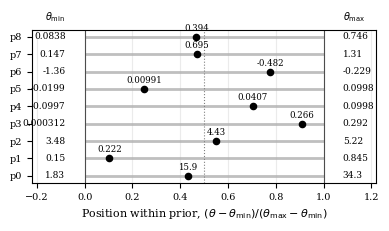

In [157]:
def fmt_val(x):
    return f"{x:.3g}"

prior_width = prior_high_np - prior_low_np
prior_frac = (true_params_plot - prior_low_np) / prior_width

fig, ax = plt.subplots(figsize=(10.0 / 2.54, 6 / 2.54))

y = np.arange(len(param_names))

ax.hlines(y, 0, 1, color="0.75", lw=2.0, zorder=1)
ax.scatter(prior_frac, y, s=20, color="black", zorder=3)

ax.axvline(0, color="0.3", lw=0.8)
ax.axvline(1, color="0.3", lw=0.8)
ax.axvline(0.5, color="0.5", lw=0.8, ls=":")

for yi, lo, hi, truth in zip(y, prior_low_np, prior_high_np, true_params_plot):
    ax.text(-0.08, yi, fmt_val(lo), ha="right", va="center", fontsize=6.5)
    ax.text(1.08, yi, fmt_val(hi), ha="left", va="center", fontsize=6.5)
    ax.text(
        prior_frac[yi],
        yi + 0.23,
        fmt_val(truth),
        ha="center",
        va="bottom",
        fontsize=6.2,
        color="black",
    )

ax.text(-0.08, len(param_names) - 0.25, r"$\theta_{\min}$", ha="right", va="bottom", fontsize=7)
ax.text(1.08, len(param_names) - 0.25, r"$\theta_{\max}$", ha="left", va="bottom", fontsize=7)

ax.set_yticks(y)
ax.set_yticklabels(names)
ax.set_xlim(-0.22, 1.22)
ax.set_xlabel(r"Position within prior, $(\theta-\theta_{\min})/(\theta_{\max}-\theta_{\min})$")
ax.grid(axis="x", alpha=0.25)

fig.tight_layout()
plt.savefig(OUTPUT_DIR / "true_params_relative_to_prior_with_ranges.jpg", dpi=300)
plt.show()

In [252]:
posterior_np = posterior_samples
param_names = list(labels_latex)

true_values = true_params_plot

summary = pd.DataFrame({
    "parameter": param_names,
    "true": true_values,
    "mean": np.mean(posterior_np, axis=0),
    "median": np.median(posterior_np, axis=0),
    "std": np.std(posterior_np, axis=0),
    "q16": np.percentile(posterior_np, 16, axis=0),
    "q84": np.percentile(posterior_np, 84, axis=0),
    "q2.5": np.percentile(posterior_np, 2.5, axis=0),
    "q97.5": np.percentile(posterior_np, 97.5, axis=0),
})
print(summary)

summary["median - true"] = summary["median"] - summary["true"]
summary["mean - true"] = summary["mean"] - summary["true"]
summary["pull"] = (summary["median"] - summary["true"]) / summary["std"]
summary["true in 68%"] = (summary["true"] >= summary["q16"]) & (summary["true"] <= summary["q84"])
summary["true in 95%"] = (summary["true"] >= summary["q2.5"]) & (summary["true"] <= summary["q97.5"])

pretty = summary.copy()
pretty["68% interval"] = pretty.apply(lambda r: f"[{r['q16']:.4g}, {r['q84']:.4g}]", axis=1)
pretty["95% interval"] = pretty.apply(lambda r: f"[{r['q2.5']:.4g}, {r['q97.5']:.4g}]", axis=1)

pretty = pretty[
    [
        "parameter",
        "true",
        "mean",
        "median",
        "std",
        "68% interval",
        "95% interval",
        "median - true",
        "pull",
        "true in 68%",
        "true in 95%",
    ]
]

display(
    pretty.style
    .format({
        "true": "{:.5g}",
        "mean": "{:.5g}",
        "median": "{:.5g}",
        "std": "{:.5g}",
        "median - true": "{:+.5g}",
        "pull": "{:+.2f}",
    })
    .background_gradient(subset=["pull"], cmap="coolwarm", vmin=-3, vmax=3)
)

              parameter       true       mean     median       std        q16  \
0                   P_0  15.851908  18.864315  18.426968  5.175428  13.609105   
1             x_{\rm c}   0.222086   0.262680   0.256354  0.055091   0.208845   
2                 \beta   4.434419   4.511251   4.532460  0.376902   4.113185   
3        \alpha_{m,P_0}   0.265726   0.185731   0.189819  0.056095   0.128001   
4  \alpha_{m,x_{\rm c}}   0.040675   0.030624   0.033540  0.038269  -0.008937   
5      \alpha_{m,\beta}   0.009909   0.035502   0.034850  0.027778   0.005275   
6        \alpha_{z,P_0}  -0.481733  -0.813143  -0.814662  0.257927  -1.091983   
7  \alpha_{z,x_{\rm c}}   0.694701   0.652347   0.655654  0.229345   0.402537   
8      \alpha_{z,\beta}   0.393559   0.412775   0.415624  0.148853   0.251164   

         q84       q2.5      q97.5  
0  24.205439  10.047699  30.044678  
1   0.316880   0.173232   0.388500  
2   4.916854   3.733635   5.150602  
3   0.243844   0.065938   0.280343  
4   

,parameter,true,mean,median,std,68% interval,95% interval,median - true,pull,true in 68%,true in 95%
0,P_0,15.852,18.864,18.427,5.1754,"[13.61, 24.21]","[10.05, 30.04]",+2.5751,+0.50,True,True
1,x_{\rm c},0.22209,0.26268,0.25635,0.055091,"[0.2088, 0.3169]","[0.1732, 0.3885]",+0.034268,+0.62,True,True
2,\beta,4.4344,4.5113,4.5325,0.3769,"[4.113, 4.917]","[3.734, 5.151]",+0.098041,+0.26,True,True
3,"\alpha_{m,P_0}",0.26573,0.18573,0.18982,0.056095,"[0.128, 0.2438]","[0.06594, 0.2803]",-0.075907,-1.35,False,True
4,"\alpha_{m,x_{\rm c}}",0.040675,0.030624,0.03354,0.038269,"[-0.008937, 0.07084]","[-0.05067, 0.09372]",-0.0071351,-0.19,True,True
5,"\alpha_{m,\beta}",0.0099093,0.035502,0.03485,0.027778,"[0.005275, 0.06558]","[-0.01413, 0.08981]",+0.02494,+0.90,True,True
6,"\alpha_{z,P_0}",-0.48173,-0.81314,-0.81466,0.25793,"[-1.092, -0.5375]","[-1.291, -0.3222]",-0.33293,-1.29,False,True
7,"\alpha_{z,x_{\rm c}}",0.6947,0.65235,0.65565,0.22934,"[0.4025, 0.891]","[0.2314, 1.093]",-0.039047,-0.17,True,True
8,"\alpha_{z,\beta}",0.39356,0.41277,0.41562,0.14885,"[0.2512, 0.5712]","[0.13, 0.6896]",+0.022065,+0.15,True,True


## Cluster Command Template

Use the case-specific NPZ from the export cell with your cluster runner. The prepared file already contains `obs`, so you do not need `PREPARED_OBS_PATH`.


In [238]:
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()

    arr = np.asarray(x)

    # Your case: dict["samples"] is shape=(), dtype=object.
    # Unpack until the real array is reached.
    while arr.shape == () and arr.dtype == object:
        arr = np.asarray(arr.item())

    return arr

In [239]:
gd_samples, names, n_params = make_getdist_samples(
    sample_sets=sample_sets,
    param_names=param_names,
    labels_latex=labels_latex,
)

KeyboardInterrupt: 

In [ ]:
s = sample_sets[0]["samples"]
print(type(s), np.asarray(s).shape, np.asarray(s).dtype)

s_unpacked = to_numpy(s)
print(type(s_unpacked), s_unpacked.shape, s_unpacked.dtype)